<a href="https://colab.research.google.com/github/GillValenzuela/curso_data_science/blob/master/DS_Ingemat_Clase_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Market Basket Analysis con Apriori

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [ ]:
# Ejemplo de dataset simple
dataset = [
    ['leche', 'pan', 'mantequilla'],
    ['pan', 'cerveza', 'huevo'],
    ['leche', 'pan', 'mantequilla', 'huevo'],
    ['pan', 'mantequilla'],
    ['leche', 'pan', 'huevo'],
]

In [ ]:
# Transformar a formato binario
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

In [ ]:
df

,cerveza,huevo,leche,mantequilla,pan
0,False,False,True,True,True
1,True,True,False,False,True
2,False,True,True,True,True
3,False,False,False,True,True
4,False,True,True,False,True


In [ ]:
# 1. Obtener ítems frecuentes
frequent_itemsets = apriori(df, min_support=0.5, use_colnames=True)

In [ ]:
frequent_itemsets

,support,itemsets
0,0.6,(huevo)
1,0.6,(leche)
2,0.6,(mantequilla)
3,1.0,(pan)
4,0.6,"(pan, huevo)"
5,0.6,"(pan, leche)"
6,0.6,"(mantequilla, pan)"


In [ ]:
# 2. Obtener reglas de asociación
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [ ]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(pan),(huevo),1.0,0.6,0.6,0.6,1.0,1.0,0.0,1.0,0.0,0.6,0.0,0.8
1,(huevo),(pan),0.6,1.0,0.6,1.0,1.0,1.0,0.0,inf,0.0,0.6,0.0,0.8
2,(pan),(leche),1.0,0.6,0.6,0.6,1.0,1.0,0.0,1.0,0.0,0.6,0.0,0.8
3,(leche),(pan),0.6,1.0,0.6,1.0,1.0,1.0,0.0,inf,0.0,0.6,0.0,0.8
4,(mantequilla),(pan),0.6,1.0,0.6,1.0,1.0,1.0,0.0,inf,0.0,0.6,0.0,0.8
5,(pan),(mantequilla),1.0,0.6,0.6,0.6,1.0,1.0,0.0,1.0,0.0,0.6,0.0,0.8


In [ ]:
# Mostrar resultados
print("\n--- Ítems Frecuentes ---")
print(frequent_itemsets)

print("\n--- Reglas de Asociación ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


--- Ítems Frecuentes ---
   support            itemsets
0      0.6             (huevo)
1      0.6             (leche)
2      0.6       (mantequilla)
3      1.0               (pan)
4      0.6        (pan, huevo)
5      0.6        (pan, leche)
6      0.6  (mantequilla, pan)

--- Reglas de Asociación ---
     antecedents    consequents  support  confidence  lift
0          (pan)        (huevo)      0.6         0.6   1.0
1        (huevo)          (pan)      0.6         1.0   1.0
2          (pan)        (leche)      0.6         0.6   1.0
3        (leche)          (pan)      0.6         1.0   1.0
4  (mantequilla)          (pan)      0.6         1.0   1.0
5          (pan)  (mantequilla)      0.6         0.6   1.0


In [ ]:
import urllib.request

# 1) URL RAW del archivo CSV en GitHub
url_raw = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv"

In [ ]:
# 2) Abrimos la URL con urllib y leemos byte‐a‐byte
response = urllib.request.urlopen(url_raw)

In [ ]:
transacciones = []
for linea in response:
    # 'linea' es un objeto bytes, p.ej. b'whole milk,rolls/buns,soda\n'
    fila = linea.decode('utf-8').strip()   # ej. "whole milk,rolls/buns,soda"
    items = fila.split(',')                # ej. ["whole milk", "rolls/buns", "soda"]
    transacciones.append(items)

In [ ]:
transacciones[0:10]

[['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'],
 ['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk'],
 ['pip fruit', 'yogurt', 'cream cheese ', 'meat spreads'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product'],
 ['whole milk', 'butter', 'yogurt', 'rice', 'abrasive cleaner'],
 ['rolls/buns'],
 ['other vegetables',
  'UHT-milk',
  'rolls/buns',
  'bottled beer',
  'liquor (appetizer)'],
 ['pot plants'],
 ['whole milk', 'cereals']]

In [ ]:
# 1) Creamos un TransactionEncoder
te = TransactionEncoder()

# 2) Ajustamos el codificador a nuestra lista de transacciones
te_ary = te.fit(transacciones).transform(transacciones)

# 3) Pasamos a DataFrame, donde las columnas son todos los productos únicos
df_binario = pd.DataFrame(te_ary, columns=te.columns_)

In [ ]:
df_binario.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
freq_items = apriori(df_binario, min_support=0.01, use_colnames=True)
reglas = association_rules(freq_items, metric="lift", min_threshold=1.5)

In [ ]:
# Mostrar resultados
print("\n--- Ítems Frecuentes ---")
print(freq_items)

print("\n--- Reglas de Asociación ---")
print(reglas[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


--- Ítems Frecuentes ---
      support                                       itemsets
0    0.033452                                     (UHT-milk)
1    0.017692                                (baking powder)
2    0.052466                                         (beef)
3    0.033249                                      (berries)
4    0.026029                                    (beverages)
..        ...                                            ...
327  0.011998  (tropical fruit, whole milk, root vegetables)
328  0.014540          (yogurt, whole milk, root vegetables)
329  0.010473                     (soda, yogurt, whole milk)
330  0.015150           (tropical fruit, yogurt, whole milk)
331  0.010880       (whipped/sour cream, yogurt, whole milk)

[332 rows x 2 columns]

--- Reglas de Asociación ---
                          antecedents                       consequents  \
0                              (beef)                (other vegetables)   
1                  (other vegetables) 

In [ ]:
print(reglas[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False).head(10))

                            antecedents                         consequents  \
243                              (curd)                (yogurt, whole milk)   
242                (yogurt, whole milk)                              (curd)   
227                   (root vegetables)    (citrus fruit, other vegetables)   
222    (citrus fruit, other vegetables)                   (root vegetables)   
332          (yogurt, other vegetables)                (whipped/sour cream)   
333                (whipped/sour cream)          (yogurt, other vegetables)   
288  (tropical fruit, other vegetables)                   (root vegetables)   
293                   (root vegetables)  (tropical fruit, other vegetables)   
3                     (root vegetables)                              (beef)   
2                                (beef)                   (root vegetables)   

      support  confidence      lift  
243  0.010066    0.188931  3.372304  
242  0.010066    0.179673  3.372304  
227  0.010371   

In [ ]:
# LDA Topic Modeling con scikit-learn y dataset de noticias

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd
import numpy as np

In [ ]:
# 1. Cargar subset de noticias
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
texts = newsgroups.data[:2000]  # Para eficiencia

In [ ]:
texts[0:10]

["\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. Actually,\nI am  bit puzzled too and a bit relieved. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. Man, they\nare killing those Devils worse than I thought. Jagr just showed you why\nhe is much better than his regular season stats. He is also a lot\nfo fun to watch in the playoffs. Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final\nregular season game.          PENS RULE!!!\n\n",
 'My brother is in the market for a high-performance video card that supports\nVESA local bus with 1-2MB RAM.  Does anyone have suggestions/ideas on:\n\n  - Diamond Stealth Pro Local Bus\n\n  - Orchid Farenheit 1280\n\n  - ATI Graphics Ultra Pro\n\n  - Any other high-per

In [ ]:
# 2. Preprocesamiento básico y vectorización
vectorizer = CountVectorizer(max_df=0.95, min_df=5, stop_words='english')
X = vectorizer.fit_transform(texts)

In [ ]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 88486 stored elements and shape (2000, 4874)>

In [ ]:
# 3. Entrenar modelo LDA
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X)

LatentDirichletAllocation(random_state=42)

In [ ]:
# 4. Mostrar palabras por tema
def mostrar_top_palabras(model, feature_names, n_palabras):
    for idx, topic in enumerate(model.components_):
        print(f"Tópico {idx+1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-n_palabras - 1:-1]]))
        print()

In [ ]:
n_palabras = 10
feature_names = vectorizer.get_feature_names_out()
mostrar_top_palabras(lda, feature_names, n_palabras)

Tópico 1:
think don people like just know say way does good

Tópico 2:
use jpeg file windows image thanks does card bit files

Tópico 3:
ed armenian people government israel states united jewish armenians history

Tópico 4:
god jesus people did like children fbi time bible just

Tópico 5:
edu com cs os comp os2 ca org david john

Tópico 6:
key 000 don use chip article car law just like

Tópico 7:
space power cost new data station high program low 93

Tópico 8:
10 11 17 van 12 det 15 34 24 30

Tópico 9:
00 game dos know don just year games right hit

Tópico 10:
information internet use privacy police mail address email anonymous security



In [ ]:
# 5. Distribución de temas en un documento de ejemplo
import matplotlib.pyplot as plt
import seaborn as sns

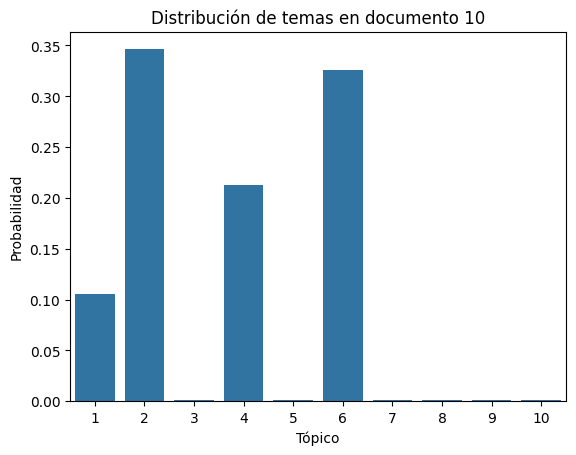

In [ ]:
sample_doc = X[30]
topic_dist = lda.transform(sample_doc)

sns.barplot(x=np.arange(1, 11), y=topic_dist[0])
plt.title("Distribución de temas en documento 10")
plt.xlabel("Tópico")
plt.ylabel("Probabilidad")
plt.show()